# Work Bench — M5 Retail Revenue Management

Exploratory notebook for building the price/demand layer of the revenue-management model on the
[M5 Forecasting](https://www.kaggle.com/competitions/m5-forecasting-accuracy) dataset
(Walmart daily unit sales for 3,049 items across 10 stores in CA, TX and WI).

**What this notebook does, end to end:**

1. **Import data** — load the three raw M5 tables (`calendar`, `sell_prices`, `sales_train_evaluation`).
2. **Dynamic price dataframe** — reshape the wide sales matrix into long (item x day) form for a single
   store (`CA_1`), attach the weekly price of each item, and roll everything up to a
   *department x day* series of total demand and demand-weighted average price.
3. **WTP and demand curve** — treat the demand-weighted distribution of realised prices as an empirical
   willingness-to-pay (WTP) distribution, estimate it with a KDE, and integrate it into a demand curve.
4. **Generating demand** — compress the department demand series with PCA and resample in the reduced
   space to generate synthetic-but-plausible demand scenarios for simulation.

Scope note: everything downstream of the import section is currently restricted to store `CA_1`.

In [171]:
# Data handling: polars is used instead of pandas because the sales/price tables run to
# millions of rows and the reshape + join steps below are much cheaper on its query engine.
import polars as pl
from pathlib import Path

# Modelling: sklearn for scaling/PCA, scipy for the kernel density estimate of WTP.
import sklearn
import numpy as np
import scipy

# Plotting.
import seaborn as sns
import matplotlib.pyplot as plt

## Import data

The three raw M5 CSVs are read straight from `data/` at the repo root. Their schemas are documented
below so the joins further down (`d` for daily grain, `wm_yr_wk` for weekly price grain) are easy to follow.

## M5 Forecasting Dataset Column Definitions

------------------------------
## 📅 calendar.csv
This file links daily sales data to specific dates, financial weeks, calendar events, and social assistance schedules.

* date: The calendar date formatted as YYYY-MM-DD.
* wm_yr_wk: A unique ID indicating the Walmart financial week. It is used to join this file with sell_prices.csv.
* weekday: The name of the day (e.g., Saturday, Sunday).
* wday: A numerical ID representing the day of the week, starting with Saturday (1) through Friday (7).
* month: The numerical month of the year (1–12).
* year: The numerical year.
* d: The specific day identifier used as headers in the training sets (e.g., d_1, d_2 ... up to d_1969).
* event_name_1: The name of a special holiday or cultural event happening on that day (e.g., SuperBowl, Thanksgiving, EidAlFitr). It is blank if no event occurs.
* event_type_1: The category classification of event_name_1 (e.g., Sporting, Cultural, National, Religious).
* event_name_2: Used on rare days where two distinct public events overlap on the same date.
* event_type_2: The category classification of event_name_2.
* snap_CA, snap_TX, snap_WI: Binary flags (0 or 1) indicating whether the stores in California, Texas, or Wisconsin allow SNAP (food stamp) purchases on that specific day.

------------------------------
## 📈 sales_train_validation.csv / sales_train_evaluation.csv
These horizontal datasets contain the historical unit transaction columns that establish the product hierarchy.

* id: A concatenated unique text key representing the specific product identifier combined with the store ID (e.g., HOBBIES_1_001_CA_1_validation).
* item_id: The granular code assigned to the product item itself (e.g., HOBBIES_1_001).
* dept_id: The department code separating broad categories (e.g., HOBBIES_1, FOODS_3).
* cat_id: The top-level category label (Hobbies, Foods, or Household).
* store_id: The store identifier where the product was sold (e.g., CA_1, TX_3, WI_2).
* state_id: The broader geographical US region (CA, TX, or WI).
* d_1 to d_1941: Sequential column headers tracking the exact quantity of units sold on that corresponding day index. This maps directly to the d column in calendar.csv.

------------------------------
## 🏷️ sell_prices.csv
This table allows you to extract revenue and price elasticity metrics across different stores.

* store_id: The store location code matching the sales matrix.
* item_id: The specific product identifier matching the sales matrix.
* wm_yr_wk: The target Walmart financial week index matching calendar.csv.
* sell_price: The specific retail dollar price of the given item at that store location during that operational week. Prices are tracked weekly because retail prices typically stay fixed for 7-day spans.






In [172]:
# Notebook lives at <repo>/code/work/, so parents[1] walks up to <repo>/ and then into data/.
data_folder = Path.cwd().parents[1] / 'data'

In [173]:
# Calendar: one row per day (1,969 days, 2011-01-29 to 2016-06-19).
# Acts as the bridge between the daily sales grain (`d`) and the weekly price grain (`wm_yr_wk`).
calendar = pl.read_csv(data_folder / 'calendar.csv')
calendar

date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
str,i64,str,i64,i64,i64,str,str,str,str,str,i64,i64,i64
"""2011-01-29""",11101,"""Saturday""",1,1,2011,"""d_1""",null,null,null,null,0,0,0
"""2011-01-30""",11101,"""Sunday""",2,1,2011,"""d_2""",null,null,null,null,0,0,0
"""2011-01-31""",11101,"""Monday""",3,1,2011,"""d_3""",null,null,null,null,0,0,0
"""2011-02-01""",11101,"""Tuesday""",4,2,2011,"""d_4""",null,null,null,null,1,1,0
"""2011-02-02""",11101,"""Wednesday""",5,2,2011,"""d_5""",null,null,null,null,1,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2016-06-15""",11620,"""Wednesday""",5,6,2016,"""d_1965""",null,null,null,null,0,1,1
"""2016-06-16""",11620,"""Thursday""",6,6,2016,"""d_1966""",null,null,null,null,0,0,0
"""2016-06-17""",11620,"""Friday""",7,6,2016,"""d_1967""",null,null,null,null,0,0,0


In [174]:
# Prices: one row per (store, item, financial week) — ~6.8M rows.
# Note this is weekly, not daily: a price holds for the whole `wm_yr_wk`. Rows are also absent
# for weeks in which an item was not stocked, which is why the join below is an inner join.
prices = pl.read_csv(data_folder/'sell_prices.csv')
prices

store_id,item_id,wm_yr_wk,sell_price
str,str,i64,f64
"""CA_1""","""HOBBIES_1_001""",11325,9.58
"""CA_1""","""HOBBIES_1_001""",11326,9.58
"""CA_1""","""HOBBIES_1_001""",11327,8.26
"""CA_1""","""HOBBIES_1_001""",11328,8.26
"""CA_1""","""HOBBIES_1_001""",11329,8.26
…,…,…,…
"""WI_3""","""FOODS_3_827""",11617,1.0
"""WI_3""","""FOODS_3_827""",11618,1.0
"""WI_3""","""FOODS_3_827""",11619,1.0


In [175]:
# Sales: wide matrix, 30,490 rows (3,049 items x 10 stores) x 1,941 day columns (d_1 ... d_1941).
# The `evaluation` split is used because it carries the full history; `validation` stops 28 days earlier.
sales = pl.read_csv(data_folder/'sales_train_evaluation.csv')
sales

id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,…,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""HOBBIES_1_001_CA_1_evaluation""","""HOBBIES_1_001""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,3,0,1,1,1,3,0,1,1,0,0,0,2,0,3,5,0,0,1,1,0,2,1,2,2,1,0,2,4,0,0,0,0,3,3,0,1
"""HOBBIES_1_002_CA_1_evaluation""","""HOBBIES_1_002""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,1,1,0,0,0,0,0
"""HOBBIES_1_003_CA_1_evaluation""","""HOBBIES_1_003""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,2,1,1,1,0,1,1,1,0,0,1,1,0,2,1,0,0,0,0,2,1,3,0,0,1,0,1,0,2,0,0,0,2,3,0,1
"""HOBBIES_1_004_CA_1_evaluation""","""HOBBIES_1_004""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,5,4,1,0,1,3,7,2,0,0,1,2,4,1,6,4,0,0,0,2,2,4,2,1,1,1,1,1,0,4,0,1,3,0,2,6
"""HOBBIES_1_005_CA_1_evaluation""","""HOBBIES_1_005""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,1,0,1,1,2,2,2,4,1,0,2,3,1,0,3,2,3,1,1,3,2,3,2,2,2,2,0,0,0,2,1,0,0,2,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""FOODS_3_823_WI_3_evaluation""","""FOODS_3_823""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",0,0,2,2,0,3,1,4,1,0,0,3,4,4,0,0,1,0,1,1,7,7,3,6,3,3,7,12,4,2,7,…,0,0,0,0,0,1,0,0,1,0,0,0,2,2,0,0,0,2,0,0,1,1,1,0,0,1,0,1,0,3,0,1,1,0,0,1,1
"""FOODS_3_824_WI_3_evaluation""","""FOODS_3_824""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",0,0,0,0,0,5,0,1,1,3,1,1,0,4,2,0,1,2,1,1,0,0,0,0,3,1,1,1,2,0,1,…,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
"""FOODS_3_825_WI_3_evaluation""","""FOODS_3_825""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",0,6,0,2,2,4,1,8,5,2,7,5,3,5,20,8,10,3,3,4,7,2,3,5,6,3,4,1,2,5,1,…,1,0,2,0,1,0,0,1,0,0,0,1,1,0,2,1,1,0,0,1,0,0,1,0,3,3,1,0,0,1,2,0,1,0,1,0,2


## Dynamic price dataframe

Goal: a single tidy table where every row is *one item on one day* with both the units sold and the
price that was in force. That requires two shape changes:

* **Sales are wide and daily** — unpivot `d_1 ... d_1941` into rows so demand becomes a column.
* **Prices are long and weekly** — join through `calendar` to map each day `d` to its `wm_yr_wk`,
  which is the key prices are stored against.

The work is scoped to store **CA_1** to keep the intermediate frames small while prototyping.
An inner join is used deliberately: item-weeks with no price row are weeks the item was not on sale,
and those zero-demand rows would otherwise distort the price statistics.

In [176]:
# --- demand side: wide daily matrix -> long (item_id, d, demand) ---
demand_ca_1 = sales.filter(pl.col('store_id')=='CA_1')

# Every column named d_* is a day of history; the rest are hierarchy/metadata columns.
day_cols = [col for col in demand_ca_1.columns if col.startswith('d_')]
demand_ca_1 = demand_ca_1.select(['item_id'] + day_cols).unpivot(
    index='item_id',
    on=day_cols,
    variable_name='d',
    value_name='demand'
)

# Attach the Walmart financial week for each day so the weekly prices can be joined on.
demand_ca_1 = demand_ca_1.join(calendar.select(
    pl.col('d', 'wm_yr_wk')
        ),
            on = 'd',
            how = 'inner'
    )

# --- price side: same store, keep only the join keys and the price itself ---
prices_ca_1 = prices.filter(
    pl.col('store_id') == 'CA_1'
).select(
    pl.col('item_id','wm_yr_wk','sell_price')
)
 




In [177]:
# Inner join drops item-days with no active price (item not stocked that week) — see note above.
merge = demand_ca_1.join(prices_ca_1, on=['item_id', 'wm_yr_wk'], how='inner')

# Recover the department from the item code: HOBBIES_1_001 -> HOBBIES_1 (first two underscore tokens).
# Cheaper than re-joining the sales hierarchy columns, and the encoding is guaranteed by the dataset.
merge = merge.with_columns(
    pl.col("item_id").str.split("_").list.slice(0, 2).list.join("_").alias("dept_id")
)
print(merge.shape)  

(4788267, 6)


In [178]:
merge

item_id,d,demand,wm_yr_wk,sell_price,dept_id
str,str,i64,i64,f64,str
"""HOBBIES_1_008""","""d_1""",12,11101,0.46,"""HOBBIES_1"""
"""HOBBIES_1_009""","""d_1""",2,11101,1.56,"""HOBBIES_1"""
"""HOBBIES_1_010""","""d_1""",0,11101,3.17,"""HOBBIES_1"""
"""HOBBIES_1_012""","""d_1""",0,11101,5.98,"""HOBBIES_1"""
"""HOBBIES_1_015""","""d_1""",4,11101,0.7,"""HOBBIES_1"""
…,…,…,…,…,…
"""FOODS_3_823""","""d_1941""",2,11617,2.98,"""FOODS_3"""
"""FOODS_3_824""","""d_1941""",0,11617,2.48,"""FOODS_3"""
"""FOODS_3_825""","""d_1941""",1,11617,3.98,"""FOODS_3"""


In [179]:
# Roll the item-level table up to one row per (day, department).
#
# `price_avg` is a *demand-weighted* average price, i.e. revenue / units, not the mean of the
# listed prices. That is the right summary here: it reflects the price customers actually paid,
# so an item that sells 500 units moves the department price more than one that sells 5.
ca_1 = merge.with_columns(
    (pl.col('demand') * pl.col('sell_price')).alias('total_price')   # revenue for this item-day
).group_by(
    ['d', 'dept_id']
).agg(
    pl.col('demand').sum().alias('total_demand'),
    pl.col('total_price').sum().alias('total_weighted_price')        # department revenue
).with_columns(
    (pl.col('total_weighted_price')/pl.col('total_demand')).round(3).alias('price_avg'),
    # Numeric day index (d_1941 -> 1941) so the series can be sorted/plotted chronologically;
    # lexical sort on the string form would put d_10 before d_2.
    pl.col('d').str.split("_").list.get(-1).cast(pl.Int32).alias('day_n')
).drop_nans(subset='price_avg')   # department-days with zero total demand give 0/0 -> NaN

In [180]:
# Sanity check on the price/demand relationship, pooled across all departments.
# A negative correlation is the expected sign for a downward-sloping demand curve.
np.corrcoef(ca_1.select(pl.col('total_demand')).to_numpy().flatten(),
            ca_1.select(pl.col('price_avg')).to_numpy().flatten())

array([[ 1.        , -0.28519683],
       [-0.28519683,  1.        ]])

## WTP and demand curve

Correlation of **-0.29** confirms the expected direction (higher average price, lower units) but is
pooled across departments, so most of it is cross-sectional: FOODS_3 is both cheap and high volume.
The per-department view below is the meaningful one.

**Method.** Each department-day contributes an observed transaction price (`price_avg`) with a weight
equal to the units sold that day (`total_demand`). Weighting the price distribution by units gives the
distribution of prices *per unit sold* — read as an empirical **willingness-to-pay (WTP)** density: how
many units clear at each price point.

1. `gaussian_kde(price_avg, weights=total_demand)` smooths that weighted histogram into a density `f(p)`.
2. The demand curve is its survival function, `D(p) = 1 - F(p) = 1 - ∫f`, approximated by a
   cumulative sum on a uniform grid. It reads as *the share of demand that would still transact at
   price p or above*, i.e. a normalised, downward-sloping demand curve.

Caveat worth keeping in mind: this infers WTP from realised prices only, so it is bounded by the price
range the retailer actually charged and inherits any confounding between price changes and seasonality.

In [181]:
ca_1

d,dept_id,total_demand,total_weighted_price,price_avg,day_n
str,str,i64,f64,f64,i32
"""d_1861""","""HOUSEHOLD_2""",188,955.04,5.08,1861
"""d_1284""","""HOUSEHOLD_1""",742,2594.31,3.496,1284
"""d_1679""","""FOODS_1""",318,675.27,2.123,1679
"""d_1""","""HOBBIES_2""",28,93.05,3.323,1
"""d_9""","""FOODS_2""",581,1947.42,3.352,9
…,…,…,…,…,…
"""d_1902""","""FOODS_3""",1688,4124.71,2.444,1902
"""d_1912""","""FOODS_2""",590,2080.41,3.526,1912
"""d_1913""","""FOODS_1""",329,754.27,2.293,1913


In [182]:
# Change this to inspect a different department: FOODS_1/2/3, HOBBIES_1/2, HOUSEHOLD_1/2.
dept_select = 'HOUSEHOLD_2'

data_dept = ca_1.filter(
    pl.col('dept_id') == dept_select
) 

# Weighting by units sold turns the distribution of observed prices into a WTP density:
# each unit sold is one "vote" for the price it was bought at.
wtp = scipy.stats.gaussian_kde(data_dept['price_avg'], weights=data_dept['total_demand'])

In [183]:
# Evaluate the density on a uniform grid spanning the observed price range.
# Uniform spacing matters: the integration below assumes a constant dx.
x_axis = np.linspace(data_dept['price_avg'].min(), data_dept['price_avg'].max(), 50)
y_axis = wtp(x_axis)

# Demand curve = survival function of WTP: D(p) = 1 - F(p), with F approximated by a
# left Riemann sum of the density. Interpretation: fraction of demand still willing to pay >= p.
# It starts near 1 at the cheapest price and falls towards 0 at the most expensive.
dx = x_axis[1] - x_axis[0]
demand_curve = 1-(np.cumsum(y_axis) * dx)

<Axes: >

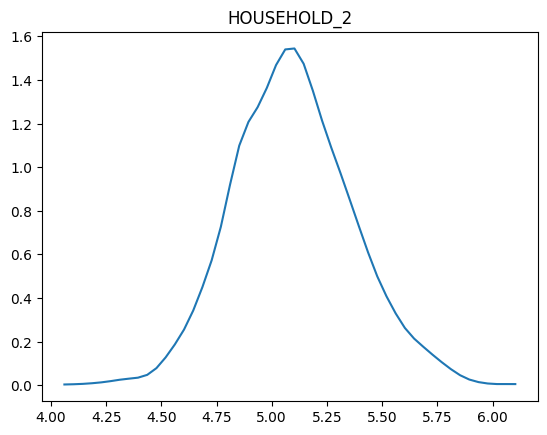

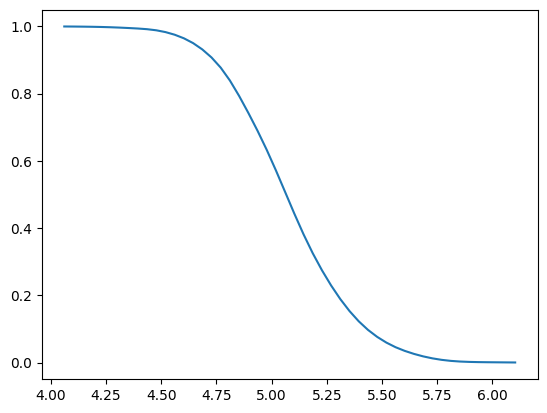

In [184]:
# Top: the WTP density itself — where in the price range the department's volume concentrates.
plt.figure()
plt.title(f'{dept_select}')
sns.lineplot(x=x_axis, y=y_axis)

# Bottom: the implied demand curve, share of demand retained at each price point.
plt.figure()
sns.lineplot(x=x_axis, y=demand_curve)

**Reading the two plots.** The first is the WTP density — its mass shows the price band where the
department's volume actually clears. The second is the cumulative demand curve; multiplying it by
price gives a revenue curve whose peak is the revenue-maximising price point for the department.
That product is the hook for the pricing/optimisation step, and is not computed here yet.

Switch `dept_select` above to compare departments: the FOODS departments concentrate in a narrow
low-price band, while HOBBIES_1 and the HOUSEHOLD departments spread over a wider range.

## Generating demand

A revenue-management policy needs to be evaluated against many plausible demand paths, not just the
single history that happened. This section builds a cheap generator for those paths.

**Approach — PCA resampling.** The 7 departments x ~1,937 days matrix is highly correlated across
departments (shared weekends, holidays, SNAP days, trend). So:

1. **Standardise per department** (each series is centred/scaled on its own mean and sd, hence the
   `.T` transposes) — otherwise FOODS_3, with ~10x the volume of HOUSEHOLD_2, dominates every component.
2. **PCA to 95% explained variance**, which reduces each department's 1,937-day series to a handful of
   scores while retaining the shared seasonal/trend structure.
3. **Perturb the scores with Gaussian noise** scaled to each component's own standard deviation
   (`sqrt(explained_variance)`, damped by 0.8), then invert PCA and the scaler.

The result is a synthetic series with the same correlation structure and seasonality as the real data
but a different realisation. Negative values from the linear inverse transform are clipped at 0, since
demand cannot be negative.

In [185]:
# Back to a wide matrix, but now at department grain: 7 rows (departments) x ~1,937 day columns.
wide_df = ca_1.pivot(
    index = 'dept_id',
    on = 'd',
    values = 'total_demand',
    aggregate_function = 'sum',
    sort_columns = True     # NB: sorts column *names* as strings -> d_1, d_10, d_100, d_1000, d_1001...
)

# Chronological list of days, derived from the numeric index (d_1, d_2, ... d_1941).
col = ca_1[['d', 'day_n']].unique().sort(by='day_n')['d']

# CHECK THIS: this overwrites the headers rather than reordering the underlying columns.
# `sort_columns=True` leaves the data in lexical day order, so column position 2 still holds
# d_10's demand while being relabelled d_2 — the series ends up time-scrambled. A reorder such as
#     wide_df = wide_df.select(['dept_id'] + list(col))
# keeps each column with its own data. It does not change the PCA much (the same permutation is
# applied to every department, so the covariance across departments is untouched), but it does
# matter for anything that reads the columns as a time series — including the plot at the end.
wide_df.columns = ['dept_id'] + list(col)

wide_df

dept_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,…,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""HOUSEHOLD_2""",181,102,157,138,143,209,233,137,142,152,109,184,223,150,222,132,119,140,131,145,210,218,148,105,129,112,94,145,234,203,130,139,137,114,137,122,…,184,234,252,129,114,121,122,115,152,246,227,150,173,141,132,160,186,194,239,132,135,104,121,170,212,201,185,149,110,122,113,171,194,200,152,107,106
"""HOUSEHOLD_1""",361,225,354,466,524,770,804,617,461,504,371,669,918,320,949,633,492,468,458,547,731,857,645,474,232,451,460,510,877,892,529,412,446,425,605,255,…,721,906,916,501,225,562,491,465,516,868,896,576,634,581,583,266,650,851,945,717,503,503,493,551,844,928,414,590,479,483,490,626,763,955,655,495,473
"""FOODS_1""",297,176,211,243,331,341,335,264,289,366,293,223,267,175,272,159,200,167,197,256,288,271,220,194,162,177,231,243,349,233,209,325,185,240,274,135,…,375,417,357,240,185,312,215,270,289,384,305,260,292,262,263,235,326,322,282,266,267,291,268,402,476,402,272,289,254,346,236,322,370,291,231,247,175
"""HOBBIES_2""",28,9,18,30,25,51,24,18,20,52,19,12,13,17,20,9,25,13,7,28,21,42,29,12,17,27,19,17,23,25,32,23,5,28,28,26,…,23,24,21,14,12,19,13,17,23,31,22,32,16,16,21,28,26,28,36,10,29,28,25,23,47,28,18,27,15,35,23,17,22,46,43,38,35
"""FOODS_2""",674,559,306,247,340,489,597,409,311,314,302,460,574,595,648,533,402,390,372,500,585,700,560,370,541,319,302,401,544,579,411,325,307,352,352,460,…,468,582,592,451,284,340,316,358,210,282,454,240,259,292,246,489,429,556,576,495,430,461,401,350,466,527,438,451,327,330,318,375,448,549,383,322,277
"""HOBBIES_1""",528,375,408,312,436,607,555,441,400,547,349,489,606,383,581,424,534,392,407,451,678,550,481,425,563,374,355,686,667,529,500,409,382,353,554,429,…,450,539,493,444,385,401,431,427,543,513,531,507,611,408,633,349,585,603,401,406,371,500,501,468,562,557,594,508,361,386,355,568,492,698,272,350,475
"""FOODS_3""",2268,1711,1579,1636,2156,2886,2923,2057,1786,1813,1539,2437,2824,1429,3488,2171,2063,1986,1928,2199,2775,3174,2287,1651,1341,1628,1776,1945,2808,2969,1930,1592,1638,1668,1971,1202,…,2410,3173,3583,2170,1179,2010,1647,1821,2366,3341,3759,2452,2469,1816,2184,1598,2533,3183,3398,2556,2375,2107,2333,2432,2723,3124,1895,2159,1730,1681,1871,2202,2858,3175,2006,1790,1822


In [186]:
# x: (7 departments, ~1,937 days) matrix of daily unit demand.
x = wide_df.select(
    pl.exclude('dept_id')
).to_numpy()

# Standardise *per department*, not per day. StandardScaler works column-wise, so x is transposed
# in and back out: each department's series gets its own mean and sd. Without this, FOODS_3
# (thousands of units/day) would swamp HOUSEHOLD_2 (hundreds) in every component.
# scaler = sklearn.preprocessing.MinMaxScaler()   # alternative: bounds to [0, 1] instead of z-scores
scaler = sklearn.preprocessing.StandardScaler()
x_scaled = scaler.fit_transform(x.T).T

# n_components=0.95 -> keep however many components explain 95% of the variance (6 here, out of 7
# possible given only 7 samples). Rounding is cosmetic, for readability of the scores below.
pca = sklearn.decomposition.PCA(n_components=0.95)   
X_reduced = pca.fit_transform(x_scaled).round(0)


X_reduced

array([[ -6.,   2.,  -2., -12., -10.,  12.],
       [ -0.,   1.,   1., -15.,  -2., -14.],
       [ -0.,  26.,  -4.,  13.,  -6.,  -3.],
       [ 33.,  -2.,  10.,   1.,   4.,   3.],
       [-11., -20.,  15.,  11.,  -7.,  -2.],
       [  2., -14., -27.,   4.,   4.,  -0.],
       [-18.,   6.,   7.,  -1.,  16.,   3.]])

In [187]:
# Jitter each department's scores in the reduced space. Noise sd is proportional to each
# component's own sd (sqrt of its explained variance), so dominant components move more than
# minor ones and the perturbation stays consistent with the data's structure.
# The 0.8 factor damps it — 1.0 would inject as much variance again as the component carries.
# Re-run this cell to draw another scenario (no seed is set, so draws are not reproducible).
noise = np.random.normal(0, 0.8 * np.sqrt(pca.explained_variance_), size=X_reduced.shape)

sampled_score = X_reduced + noise

# Invert both transforms to get back to unit demand: PCA space -> z-scores -> units.
sampled_scaled = pca.inverse_transform(sampled_score)
sampled_demand = scaler.inverse_transform(sampled_scaled.T).T.round(0)

# The inverse transform is linear and unconstrained, so it can produce negative units; floor at 0.
sampled_demand = np.clip(sampled_demand, 0, None)

<Axes: >

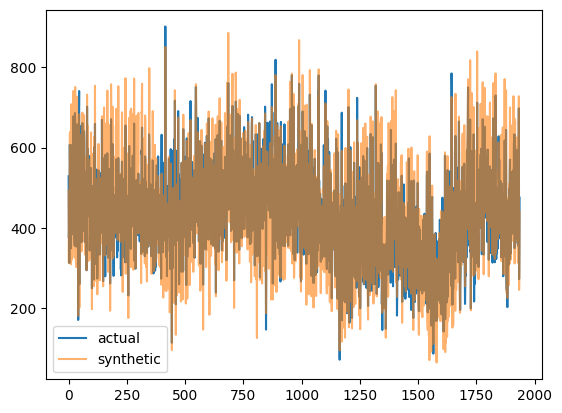

In [ ]:
# Visual check: does the synthetic series look like the real one?
# Row order matches wide_df: 0 HOBBIES_2, 1 FOODS_3, 2 HOBBIES_1, 3 HOUSEHOLD_1,
#                            4 FOODS_1,   5 FOODS_2, 6 HOUSEHOLD_2.
sampled_demand, x

idx = 5   

sns.lineplot(x[idx, :], label='actual')
sns.lineplot(sampled_demand[idx, :], label='synthetic', alpha=0.6)